# Exploratory Data Analysis on Laptop Price Dataset

## Description
This project analyzes laptop prices based on features like RAM, processor, and storage.



## EDA Process

- Data loading using Pandas
- Data inspection using head(), info(), and describe()
- Handling missing values
- Removing duplicates
- Converting RAM and weight into numeric format


In [1]:
import pandas as pd
import numpy as np
df = pd.read_csv("../data/laptop_price.csv", encoding='latin-1')
df.head()


,laptop_ID,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_euros
0,1,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,1339.69
1,2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
2,3,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,575.00
3,4,Apple,MacBook Pro,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,2537.45
4,5,Apple,MacBook Pro,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,1803.60


In [2]:
print("Shape of the dataset:",df.shape)
df.info()


Shape of the dataset: (1303, 13)
<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_ID         1303 non-null   int64  
 1   Company           1303 non-null   str    
 2   Product           1303 non-null   str    
 3   TypeName          1303 non-null   str    
 4   Inches            1303 non-null   float64
 5   ScreenResolution  1303 non-null   str    
 6   Cpu               1303 non-null   str    
 7   Ram               1303 non-null   str    
 8   Memory            1303 non-null   str    
 9   Gpu               1303 non-null   str    
 10  OpSys             1303 non-null   str    
 11  Weight            1303 non-null   str    
 12  Price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 132.5 KB


In [3]:
df.describe()

,laptop_ID,Inches,Price_euros
count,1303.000000,1303.000000,1303.000000
mean,660.155794,15.017191,1123.686992
std,381.172104,1.426304,699.009043
min,1.000000,10.100000,174.000000
25%,331.500000,14.000000,599.000000
50%,659.000000,15.600000,977.000000
75%,990.500000,15.600000,1487.880000
max,1320.000000,18.400000,6099.000000


In [4]:
df.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

## Initial Observations

- Dataset loaded successfully
- Contains multiple features related to laptop specifications
- No columns contains missing values

## Data Cleaning

In [6]:
df.isnull().sum()

laptop_ID           0
Company             0
Product             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price_euros         0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

Since 0 duplicate value is there, therefore no need to remove the duplicates.
otherwise we would use 
    df = df.drop_duplicates()

In [8]:
df.columns

Index(['laptop_ID', 'Company', 'Product', 'TypeName', 'Inches',
       'ScreenResolution', 'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight',
       'Price_euros'],
      dtype='str')

In [9]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   laptop_id         1303 non-null   int64  
 1   company           1303 non-null   str    
 2   product           1303 non-null   str    
 3   typename          1303 non-null   str    
 4   inches            1303 non-null   float64
 5   screenresolution  1303 non-null   str    
 6   cpu               1303 non-null   str    
 7   ram               1303 non-null   str    
 8   memory            1303 non-null   str    
 9   gpu               1303 non-null   str    
 10  opsys             1303 non-null   str    
 11  weight            1303 non-null   str    
 12  price_euros       1303 non-null   float64
dtypes: float64(2), int64(1), str(10)
memory usage: 132.5 KB




### Correct Data Types

* `price_euros` → **float**
* `inches` → **float**
* `laptop_id` → **int**

---

### Datas that should Not Be Strings

* `ram` → values like `"8GB"`
* `weight` → values like `"2.3kg"`

These should be **converted to numeric types** (e.g., `8`, `2.3`) for proper analysis and processing.




### Fix RAM column

In [11]:
df['ram'] = df['ram'].str.replace('GB', '')
df['ram'] = df['ram'].astype(int)

### Fix Weight column

In [12]:
df['weight'] = df['weight'].str.replace('kg', '')
df['weight'] = df['weight'].astype(float)

In [13]:
df.to_csv("../data/cleaned_laptop_price.csv", index=False)

## Outlier Detection


### Box plot

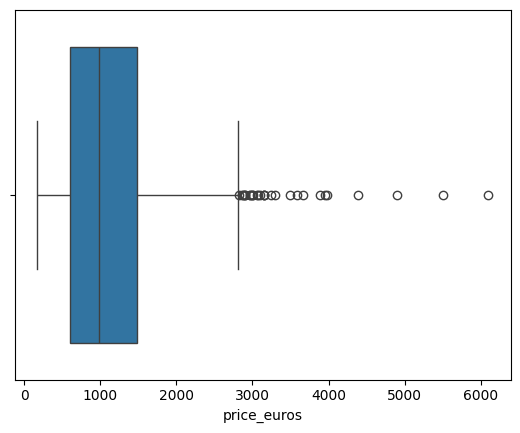

In [32]:
sns.boxplot(x=df['price_euros'])
plt.show()

### Identify actual outliers

In [33]:
Q1 = df['price_euros'].quantile(0.25)
Q3 = df['price_euros'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['price_euros'] > Q3 + 1.5*IQR)]
outliers[['company','typename','price_euros']].head()

,company,typename,price_euros
17,Apple,Ultrabook,2858.0
190,Lenovo,2 in 1 Convertible,2824.0
196,Razer,Gaming,6099.0
204,Dell,Workstation,3055.0
238,Asus,Gaming,3890.0


Outliers were identified using box plot visualization on the price feature.

### Observations:
- Some high-price outliers were detected.
- These represent premium or high-end laptops.
- Since these values are valid and not errors, they were retained in the dataset.

## Exploratory Data Analysis and Insights

In this section, we analyze the dataset using visualizations to identify patterns, trends, and relationships between laptop features and their prices.

## Objectives

1. To analyze the distribution of laptop prices and identify common price ranges.
2. To compare laptop prices across different companies and identify premium and budget brands.
3. To examine the relationship between RAM and laptop price.
4. To analyze how different types of laptops affect pricing.
5. To study the relationship between laptop weight and its price.

## 1. Which price range is most common?

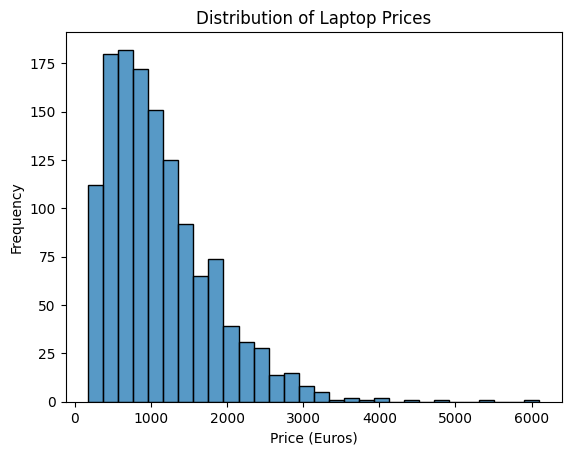

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df['price_euros'], bins=30)
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price (Euros)")
plt.ylabel("Frequency")
plt.show()

### Insight:
- Most laptops are concentrated in the mid-price range.
- A smaller number of laptops are in the high-price category.
- The distribution shows that extremely expensive laptops are less common.
- This indicates that the majority of users prefer mid-range laptops.

## 2. How does laptop price vary across different companies?

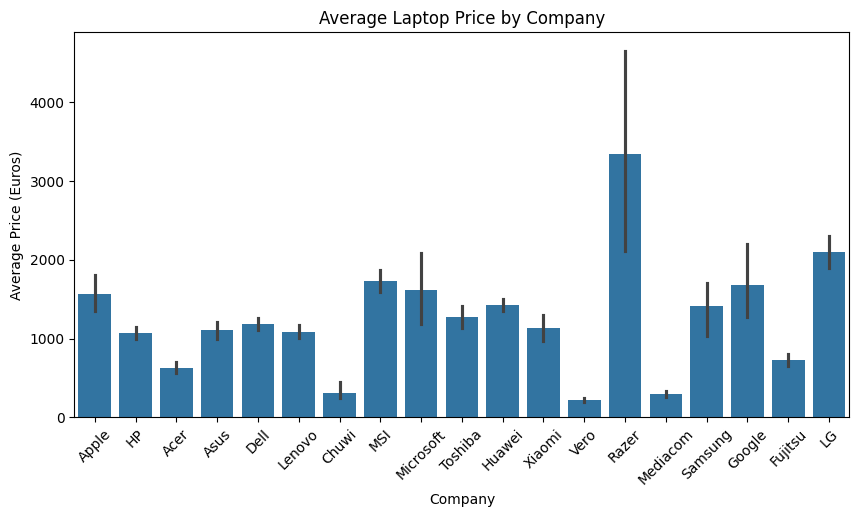

In [16]:
plt.figure(figsize=(10,5))
sns.barplot(x='company', y='price_euros', data=df)
plt.xticks(rotation=45)
plt.title("Average Laptop Price by Company")
plt.xlabel("Company")
plt.ylabel("Average Price (Euros)")
plt.show()

### Insight:
- Some companies have significantly higher average laptop prices.
- These brands are likely positioned in the premium segment.
- Other companies offer more affordable laptops, targeting budget users.
- This shows that brand plays an important role in determining laptop price.

## 3. Does RAM affect laptop price?

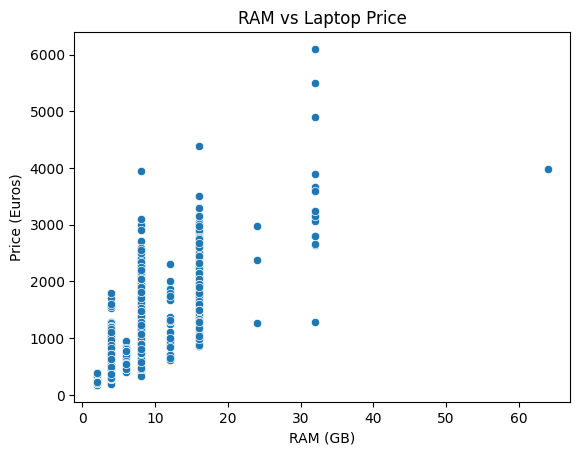

In [17]:
plt.figure()
sns.scatterplot(x='ram', y='price_euros', data=df)
plt.title("RAM vs Laptop Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (Euros)")
plt.show()

### Insight:
- There is a clear positive relationship between RAM and laptop price.
- Laptops with higher RAM (16GB, 32GB) are generally more expensive.
- Lower RAM laptops (4GB, 8GB) fall in the lower price range.
- This indicates that RAM is a key factor influencing laptop pricing.

## 4. How does the type of laptop affect its price?

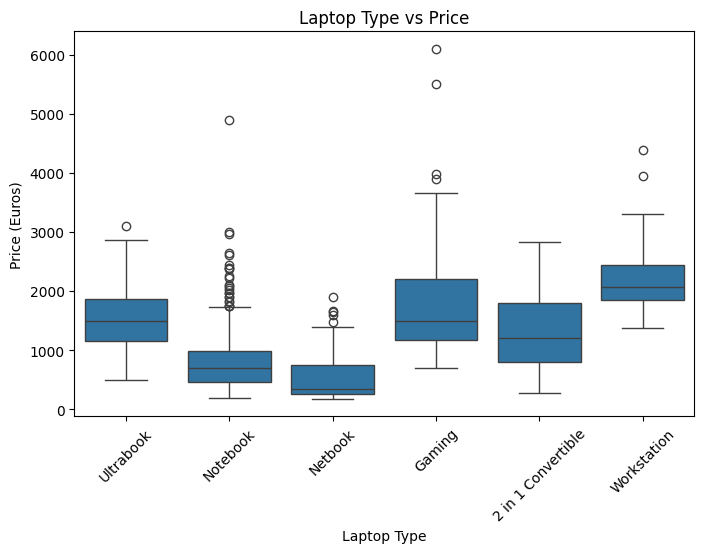

In [18]:
plt.figure(figsize=(8,5))
sns.boxplot(x='typename', y='price_euros', data=df)
plt.xticks(rotation=45)
plt.title("Laptop Type vs Price")
plt.xlabel("Laptop Type")
plt.ylabel("Price (Euros)")
plt.show()

### Insight:
- Gaming and workstation laptops tend to have higher price ranges.
- Ultrabooks are also relatively expensive due to their design and portability.
- Notebooks and netbooks are generally more affordable.
- This shows that laptop type plays a significant role in pricing.

## 5. Does laptop weight influence its price?

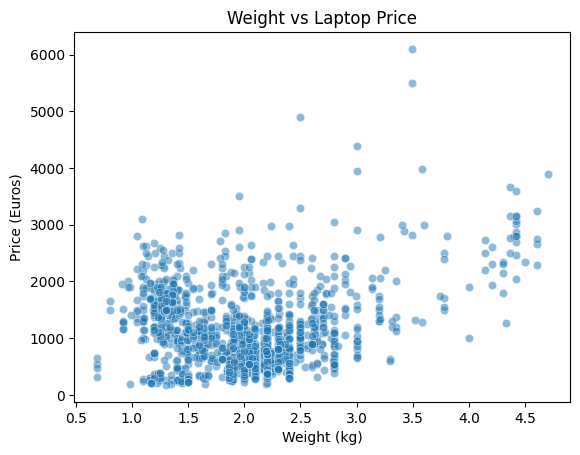

In [20]:
plt.figure()
sns.scatterplot(x='weight', y='price_euros', data=df, alpha=0.5)
plt.title("Weight vs Laptop Price")
plt.xlabel("Weight (kg)")
plt.ylabel("Price (Euros)")
plt.show()

### Insight:
- There is no strong relationship between weight and laptop price.
- Both lightweight and heavier laptops are found across different price ranges.
- Some lightweight laptops are expensive due to premium design and portability.
- Weight alone is not a major factor affecting laptop pricing.

## Correlation Analysis

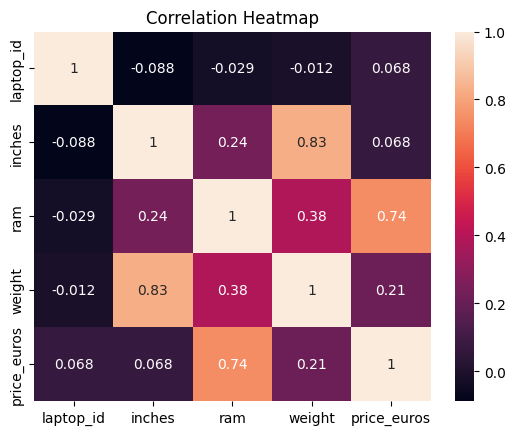

In [21]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### Insight:
- Price shows a strong positive correlation with RAM.
- Other features like weight have weaker relationships with price.
- This confirms that RAM is a key factor influencing laptop pricing.

## Check if high RAM laptops are significantly more expensive than low RAM laptops

### T-Test Analysis (RAM vs Price)

- Null Hypothesis (H0): There is no significant difference in price between high RAM and low RAM laptops.
- Alternative Hypothesis (H1): There is a significant difference in price.

Result:
- If p-value < 0.05 → Reject H0
- If p-value > 0.05 → Accept H0
  

In [34]:
high_ram = df[df['ram'] >= 16]['price_euros']
low_ram = df[df['ram'] <= 8]['price_euros']

In [35]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(high_ram, low_ram)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 27.722340071952967
P-Value: 8.613335187745555e-133


**Conclusion**:
Here p-value is < 0.05. Hence the test shows that RAM has a statistically significant impact on laptop pricing.

## Summary of Findings

- Laptop price is strongly influenced by RAM and brand.
- Premium laptop types such as gaming and ultrabooks are more expensive.
- Most laptops fall within a mid-range price category.
- Weight has minimal impact on pricing compared to performance features.

## Final Conclusion

In this project, exploratory data analysis was performed on a laptop dataset to understand the factors affecting laptop pricing.

Key findings from the analysis include:

- Laptop prices are mostly concentrated in the mid-range category, with fewer high-end premium devices.
- Brand plays a significant role in pricing, with some companies consistently offering higher-priced laptops.
- RAM is one of the most influential factors affecting price, with higher RAM configurations leading to higher costs.
- Laptop type also impacts pricing, where gaming and ultrabook categories are generally more expensive.
- Weight does not show a strong relationship with price, indicating that pricing is more dependent on performance features than physical characteristics.

Overall, the analysis highlights that performance-related features and brand positioning are the primary drivers of laptop prices.

### CPU Impact on Price

In [22]:
df['CPU_brand'] = df['cpu'].apply(lambda x: x.split()[0])
df.groupby('CPU_brand')['price_euros'].mean().sort_values(ascending=False)

CPU_brand
Intel      1152.214145
Samsung     659.000000
AMD         560.638871
Name: price_euros, dtype: float64

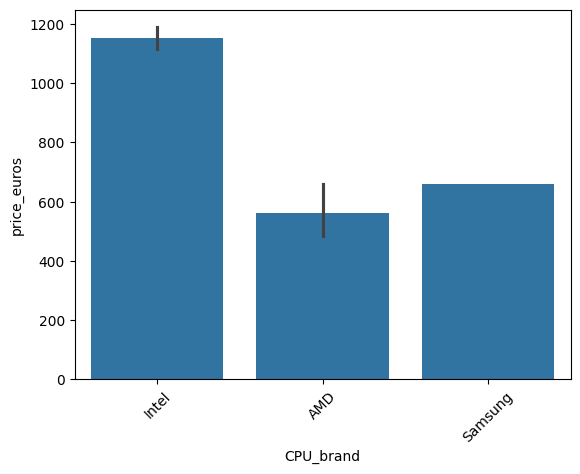

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='CPU_brand', y='price_euros', data=df)
plt.xticks(rotation=45)
plt.show()

### Storage Impact (SSD vs HDD)

In [24]:
df['Storage_type'] = df['memory'].apply(lambda x: 'SSD' if 'SSD' in x else 'HDD')

In [25]:
df.groupby('Storage_type')['price_euros'].mean()

Storage_type
HDD     637.858130
SSD    1388.789336
Name: price_euros, dtype: float64

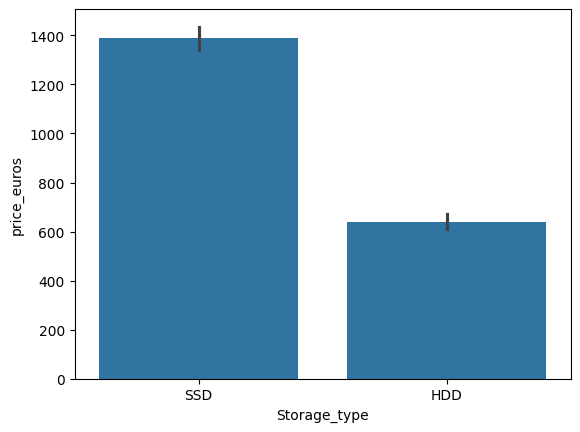

In [26]:
sns.barplot(x='Storage_type', y='price_euros', data=df)
plt.show()